In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

'/Users/smin/IdeaProjects/crop-yield-prediction/notebooks'

Kaggle Agriculture Crop Yield (합성 데이터, 100만 행)
농경지 환경/관리 조건 + 그때의 수확량

" 어떠한 환경에서 어떤 작물을 키웠는데 1헥타르당 수확량이 몇 톤 나왔다.. " 
-> 우리는 어떠한 환경과 수확량의 모종의 관계를 상관계수 분석을 통해 분석하고 회귀예측을 통해 수확량의 연속적인 값을 예측한다. 모델은 랜덤포레스트회귀 를 베이스라인으로 두고 평가지표는 MAE, RMSE 를 사용한다.

먼저 랜덤포레스트회귀 와 평가지표를 이것으로 둔 이유는 

작물 수확량은 환경 변수와 비선형 관계일 가능성이 높다. -> 왜 가능성 높음?
-> 식물 생장 변수에는 최적점이 있다 식물 마다는 다르겠지만 강수량, 기온, 일조량 등 각 환경변수에 대한
최적의 조건 값이 있다 너무 적거나 너무 많거나 가 좋은 값이 아닌 평균적인 값의 구간이 있으므로
선형적인 관계는 비현실적인 결론으로 내딛어진다. 따라서 자연현상은 임계점과 포화가 흔하다
→ 농학에서 잘 알려진 패턴: Liebig의 최소량 법칙, 종 모양 반응 곡선 (Claude)

선형 회귀는 직선 관계만 잡지만 RF는 곡선 / 임계 패턴도 자동으로 처리 -> 어떻게 처리하는지?
-> 임계값 자체가 비선형 처리의 핵심이다. 임계값들의 조합으로 계단 함수를 만들고 트리 100개 평균(RF)
  -> 부드러운 곡선을 근사한다.
    -> 곡선을 직선 조각 수백 개로 나누어서 그린다고 생각하면 됨 ( 적분 )
    
선형 회귀는 정규성/등분산성/독립성 등 가정 검증해야하지만 RF는 비모수 모델이라 가정이 존재하지 않는다 -> 비모수 모델은 뭐고 가정은 왜 존재하지 않음?
-> 모수(Parametric) : 데이터가 특정 분포 또는 관계를 따른다고 가정 그리고 그 파라미터를 추정
  -> 선형 회귀(직선 관계 가정), 로지스틱 회귀, t-test
    -> 정규성 , 등분산성, 독립성, 선형성
-> 비모수(non-parametric) : 사전 가정 없이 데이터 자체에서 패턴 학습
  -> RF, KNN, 결정 트리
    -> 분포 가정은 사실상 없다.
선형회귀는 "Y = β₀ + β₁X + ε, ε ~ N(0,σ²)" 식으로 확률 분포 가정이 박혀있다. RF 는 그냥 데이터 보고 임계값 찾자 이므로 가정 자체가 존재할 수 없다.

트리기반이라 극단값에 덜 끌려간다. -> 왜 트리기반인지? 그리고 트리기반은 왜 극단값에 덜 끌려가나?
-> 랜덤 포레스트의 정의는 여러 결정 트리의 앙상블(평균) 이름 그대로 랜덤한 트리들의 숲 트리가 RF의 기본 단위
 -> 트리 분기 기준으로 값이 임계값보다 큰가 / 작은가 는 값이 100 이던 1000이던 같은 분기 그룹으로 들어간다.
 하지만 선형 회귀는 제곱합(SSE) 최소화 -> 큰 값이 회귀선을 강하게 끌어당긴다.
 트리는 정렬 후 분기점만 찾아서 그룹을 나누기 때문에 절대값 크기 영향이 거의 존재하지 않음 ㅇㅇ

예를 들어 키로 줄을 세운다하면 1등이 180 이든 250이든 1등은 1등임, 평균은 250 이 끼면 평균이 올라가지만 키 큰 그룹 작은 그룹을 나누는데에는 영향이 거의 없음

표준화/정규화 안 해도 잘 동작 -> 왜?

표준화와 정규화가 필요한 모델은 거리기반(KNN, K-means), 그레디언트 기반(SVM, 신경망), 정규화 회귀(Ridge, Lasso). 이런 모델들은 스케일 큰 피처가 손실함수와 거리를 지배함

벗. 트리는 분기점만 찾으면 된다. -> 강수량 > 500 분기 결과와 표준화된 강수량 > 0.5 의 분기 결과는 완전히 동일 분기는 순서만 보고 크기는 안본다. 그래서 스케일 중요하지 않음 ㅇㅇ


평가지표를 MAE + RMSE 를 사용한 이유는

MAE (평균 절대 오차) -> 예측과 실제 차이 절대값의 평균
-> 종속 변수와 같은 단위 -> 평균 0.5톤 오차 식으로 직관적 해석이 가능하다

RMSE (평균 제곱근 오차) -> 차이 제곱 평균의 루트 -> 큰 오차에 패널티를 더 부과한다. -> 회귀의 표준 지표

MAE 는 평균적 오차 크기는 알지만 큰 오차(이상치)가 있는지는 알 수 없다.
RMSE 는 큰 오차에는 민감하지만 평균적인 오차에 대해서는 직관력이 떨어진다.

R^2은 왜 안씀? -> 가능하긴 한데 분산의 X% 설명은 이해하기 어려움 -> 만약 의사결정에 R^2 을 쓴다면 
MAE, RMSE 보다 해석력이 비슷하거나 직관적이어야 하는데 그렇지 못함 R^2 0.85 이해하기 쉬움? 
-> R² 0.85 의미 = "종속변수 분산의 85%를 모델이 설명함" -> 일반인이 분산 알아? 설명 알아?
MAE 0.5톤 의미 = "평균 0.5톤 빗나감" -> 직관적 농부도 이해한다

In [15]:
df = pd.read_csv("../data/crop_yield.csv")
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [16]:
df.shape

(1000000, 10)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  str    
 1   Soil_Type               1000000 non-null  str    
 2   Crop                    1000000 non-null  str    
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  str    
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 62.9 MB


In [18]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [19]:
df.isnull().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

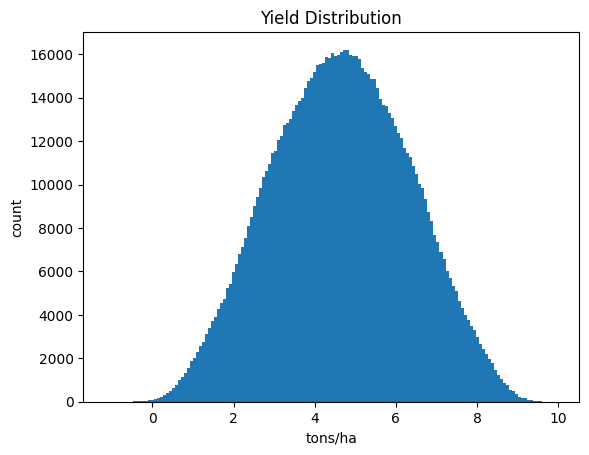

In [27]:
#그래서 왜 종속변수만 히스토그램을 쓰는지? 
# -> 타겟 분포가 곧 문제 정의 -> 모델이 맞춰야 하는 값 -> 문제가 얼마나 어려운가를 보여줌
# 타겟 분포가 뭔데?
# 타겟 분포를 보고 정상적인 예측값의 범위가 어느정도로 나오는지 볼 수 있음
# 또한 평가지표 해석에 직접적으로 다가갈 수 있음 
# 모델 / 전처리 선택에 영향
# 정규분포는 그대로 회귀해도 좋음 / 오른쪽으로 쏠림은 로그 변환 고려 / 
# 이중 분포는 두 집단이 섞여 있다는 신호로 분리해야할 수있음
plt.hist(df['Yield_tons_per_hectare'], bins=150)
plt.title('Yield Distribution')
plt.xlabel('tons/ha')
plt.ylabel('count')
plt.show()

In [29]:
# 1. 수치형 컬럼만 골라서 상관행렬 계산
numeric_cols = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest', 'Yield_tons_per_hectare']
corr = df[numeric_cols].corr()


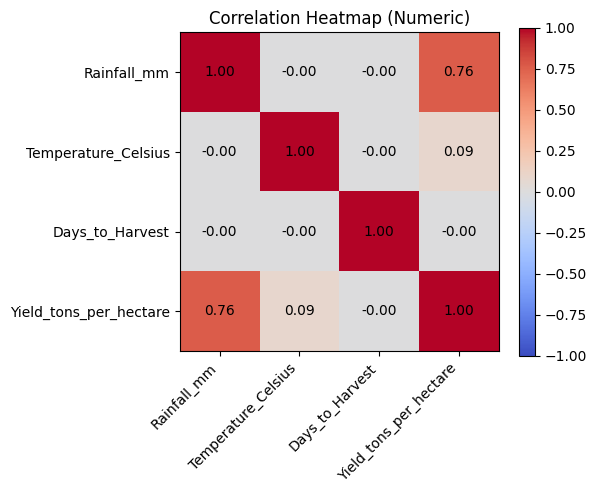

In [31]:
# 2. 히트맵 그리기
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

# 3. 축 라벨 (컬럼명 표시)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)

# 4. 셀 안에 숫자 표시 (annotation)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center')

plt.title('Correlation Heatmap (Numeric)')
plt.tight_layout()
plt.show()

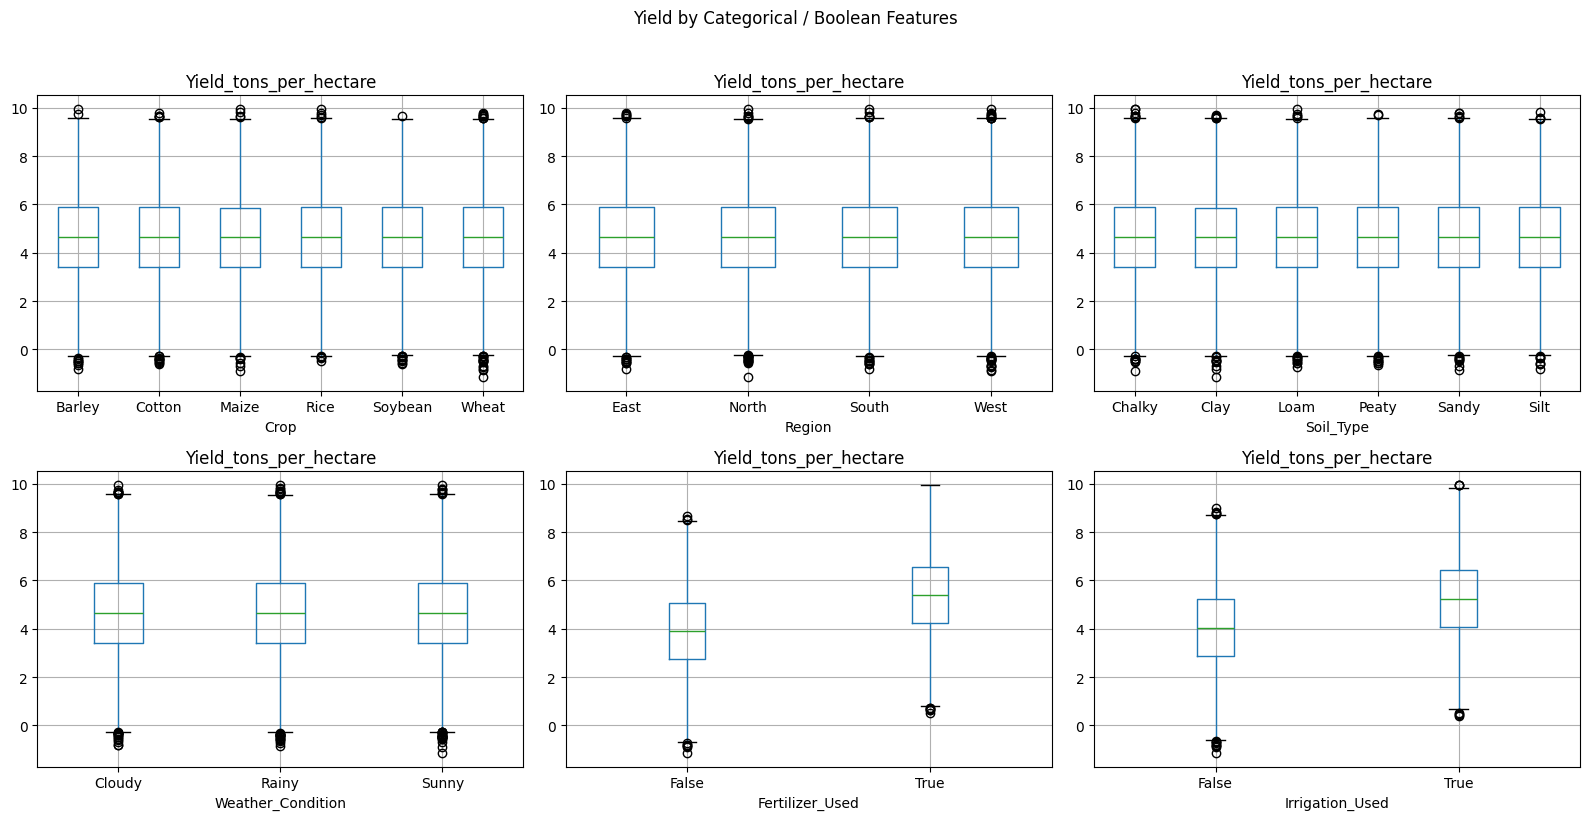

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 범주형 4개
df.boxplot(column='Yield_tons_per_hectare', by='Crop',              ax=axes[0, 0])
df.boxplot(column='Yield_tons_per_hectare', by='Region',            ax=axes[0, 1])
df.boxplot(column='Yield_tons_per_hectare', by='Soil_Type',         ax=axes[0, 2])
df.boxplot(column='Yield_tons_per_hectare', by='Weather_Condition', ax=axes[1, 0])

# 불리언 2개
df.boxplot(column='Yield_tons_per_hectare', by='Fertilizer_Used',   ax=axes[1, 1])
df.boxplot(column='Yield_tons_per_hectare', by='Irrigation_Used',   ax=axes[1, 2])

plt.suptitle('Yield by Categorical / Boolean Features', y=1.02)
plt.tight_layout()
plt.show()

같은 피처에서 그룹 간:
- 박스/중앙값 위치가 비슷  →  그룹별 차이 없음  →  예측에 무용
- 박스/중앙값 위치가 다름  →  그룹별 차이 있음  →  예측에 유용

판단은 중앙값을 비교하는거임

위 플롯들을 보면 상단 패널들은 각 박스의 중앙값이 전부 다 같기 때문에 수확량이 작물 종류, 지역, 토양에 무관한 것을 알 수 있음

하단 을 보면 날씨 조건 까지는 중앙값이 같기에 무관하고 

Fertilizer_Used, Irrigation_Used 의 중앙값이 다른 것을 알 수 있으므로 예측에 유용한 것을 알 수 있음

EDA 는 이정도로 끝 따라서 수확량에 대한 좋은 피쳐는 플롯에서 Fertilizer_Used, Irrigation_Used 2개
히트맵에서 Rain_Fall 1개 

하지만 RF 학습 후 .feature_importances_로 다시 검증해야함 비선형/상호작용 효과는 시각화에서 알 수 없으므로